In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import os
import numpy as np
import random
import logging
import sys
from datetime import datetime


# Khoi tao moi truong

In [2]:
# Khoi tao moi truong
env = gym.make("FrozenLake-v1", is_slippery=True) # True để có stochastic (trượt)

n_states = env.observation_space.n
n_actions = env.action_space.n

# Khởi tạo Q-table + tham số


In [3]:
# Khởi tạo Q-table (|S| x |A|) với giá trị ban đầu = 0
Q_sarsa = np.zeros((n_states, n_actions))

""""
 Thiết lập siêu tham số 
 – Learning rate 𝛼 
 – Discount factor 𝛾 
 – Exploration rate 𝜖 
 – Số episode huấn luyện
 """
#Hyperameters 
alpha = 0.1   # learning rate
gamma = 0.99  # discount factor
epsilon = 1.0 # exploration rate
epsilon_decay = 0.999
epsilon_min = 0.01

episodes = 10000




# Hàm chọn action theo ε-greedy

In [4]:
def epsilon_greedy(Q, state, epsilon):
    # Chon ngau nhien voi xac suat epsilon
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    #Chon actiopn tot nhat theo q_table
    else:
        return np.argmax(Q[state])

# Huấn luyện SARSA

In [5]:
rewards_sarsa = []
epsilon_sarsa = 1.0  # reset rieng cho SARSA, tranh anh huong khi rerun cell

for ep in range(episodes):
    # Reset env -> trang thai ban dau s
    state, _ = env.reset()

    # Chon Action a the e-greedy
    action = epsilon_greedy(Q_sarsa, state, epsilon_sarsa)

    total_reward = 0
    done = False

    while not done:
        # Thuc hien action a
        next_state, reward, terminated, truncated, _ = env.step(action)
        done =  terminated or truncated

        # CHon action tiep theo a' the e-greedy
        next_action = epsilon_greedy(Q_sarsa, next_state, epsilon_sarsa)

        # SARSA update
        # Q(s,a) ← Q(s,a) + α [r + γ Q(s',a') - Q(s,a)]
        Q_sarsa[state, action] += alpha * (
            reward + gamma * Q_sarsa[next_state, next_action] - Q_sarsa[state, action]
        )

        # Cap nhat state, action
        state = next_state
        action = next_action

        total_reward += reward

    # Giam epsilon sau moi episode
    epsilon_sarsa = max(epsilon_min, epsilon_sarsa * epsilon_decay)

    rewards_sarsa.append(total_reward)

# Cài đặt Q-learning (để so sánh)

In [6]:
Q_qlearning = np.zeros((n_states, n_actions))

epsilon_q = 1.0  # reset rieng cho Q-learning
rewards_q = []

for ep in range(episodes):
    state,_ = env.reset()
    total_reward = 0
    done = False

    while not done:
        # Chọn action theo ε-greedy
        action = epsilon_greedy(Q_qlearning, state, epsilon_q)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q-learning update:
        # Q(s,a) ← Q(s,a) + α [r + γ max Q(s',a') - Q(s,a)]
        Q_qlearning[state, action] += alpha * (
            reward + gamma * np.max(Q_qlearning[next_state]) - Q_qlearning[state, action]
        )

        state = next_state
        total_reward += reward

    epsilon_q = max(epsilon_min, epsilon_q * epsilon_decay)
    rewards_q.append(total_reward)

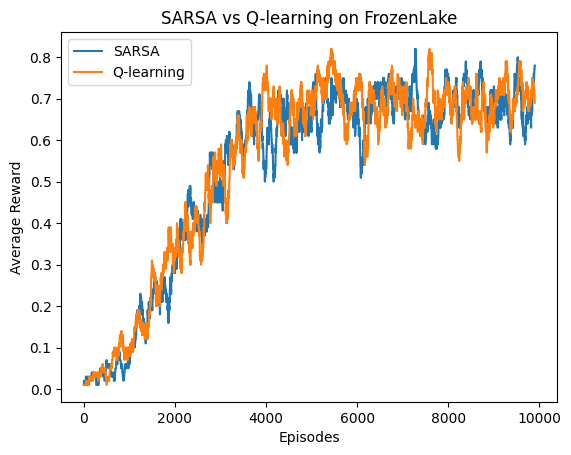

In [7]:
# Làm mượt bằng moving average
def moving_average(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.plot(moving_average(rewards_sarsa), label="SARSA")
plt.plot(moving_average(rewards_q), label="Q-learning")

plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.legend()
plt.title("SARSA vs Q-learning on FrozenLake")
plt.show()

In [8]:
print("Q-table (Q-learning):")
print(Q_qlearning)

Q-table (Q-learning):
[[0.55699128 0.53948395 0.52932294 0.52637532]
 [0.30096696 0.29840032 0.38244168 0.51373818]
 [0.42630166 0.42317175 0.40737405 0.48521903]
 [0.24122942 0.28767849 0.31934116 0.47104053]
 [0.58517178 0.43368486 0.39471049 0.2667075 ]
 [0.         0.         0.         0.        ]
 [0.15850069 0.18876124 0.27373866 0.19006174]
 [0.         0.         0.         0.        ]
 [0.29751101 0.41120968 0.27322907 0.63147465]
 [0.51773066 0.69833675 0.48924922 0.27578651]
 [0.62973101 0.44663805 0.30806584 0.31520766]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.50235244 0.4507531  0.76439927 0.62169772]
 [0.75150887 0.86990349 0.78947415 0.71182548]
 [0.         0.         0.         0.        ]]


In [9]:
def train_expected_sarsa(
    epsilon_start,
    episodes=10000,
    epsilon_decay=0.995,
    epsilon_min=0.01,
    use_decay=False,
):
    Q = np.zeros((n_states, n_actions))
    rewards = []
    epsilon = epsilon_start

    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            # ε-greedy action
            action = epsilon_greedy(Q, state, epsilon)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Tính expected value theo policy epsilon-greedy hiện tại
            probs = np.ones(n_actions) * epsilon / n_actions
            best_action = np.argmax(Q[next_state])
            probs[best_action] += (1.0 - epsilon)

            expected_q = np.sum(probs * Q[next_state])

            # Update Expected SARSA
            Q[state, action] += alpha * (
                reward + gamma * expected_q - Q[state, action]
            )

            state = next_state
            total_reward += reward

        if use_decay:
            epsilon = max(epsilon_min, epsilon * epsilon_decay)

        rewards.append(total_reward)

    return Q, rewards

In [10]:
# SARSA
# Q-learning

# Expected SARSA: giu epsilon co dinh (0.5 va 0.1) de dung voi label va de thay su khac biet ro
Q_exp_sarsa_05, rewards_exp_05 = train_expected_sarsa(
    epsilon_start=0.5,
    episodes=episodes,
    use_decay=False,
)

Q_exp_sarsa_01, rewards_exp_01 = train_expected_sarsa(
    epsilon_start=0.1,
    episodes=episodes,
    use_decay=False,
)

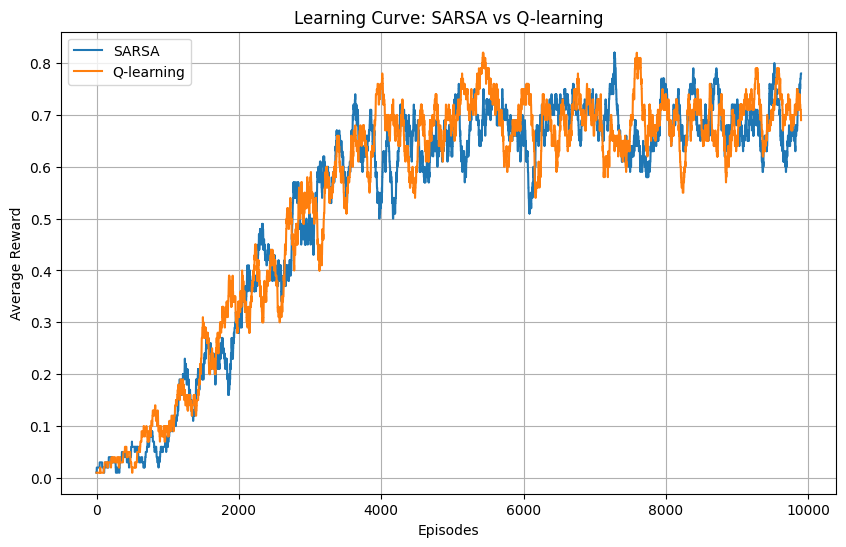

In [11]:
def moving_average(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10,6))

# Chi so sanh 2 thuat toan chinh
plt.plot(moving_average(rewards_sarsa), label="SARSA")
plt.plot(moving_average(rewards_q), label="Q-learning")

plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.title("Learning Curve: SARSA vs Q-learning")
plt.legend()
plt.grid()
plt.show()

Learning Curve: SARSA vs Q-learning (Average Reward)

Cả 2 đều tăng từ mức thấp lên mức cao hơn theo episode -> agent có học.
Q-learning thường tăng nhanh hơn ở giai đoạn đầu và dao động ít hơn.
SARSA thường tăng chậm hơn nhưng ổn định dần về sau.
Với is_slippery=True, việc dao động ở đoạn giữa/cuối là bình thường (môi trường ngẫu nhiên).

In [12]:
# Evaluate greedy policy cho SARSA va Q-learning

def evaluate_policy(Q, tests=1000):
    wins = 0
    returns = []

    for _ in range(tests):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = np.argmax(Q[state])
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

        returns.append(total_reward)
        if total_reward > 0:
            wins += 1

    return wins / tests, float(np.mean(returns))

win_sarsa, ret_sarsa = evaluate_policy(Q_sarsa)
win_q, ret_q = evaluate_policy(Q_qlearning)

print(f"SARSA     -> win_rate={win_sarsa:.3f}, avg_return={ret_sarsa:.3f}")
print(f"Q-learning-> win_rate={win_q:.3f}, avg_return={ret_q:.3f}")

SARSA     -> win_rate=0.721, avg_return=0.721
Q-learning-> win_rate=0.755, avg_return=0.755


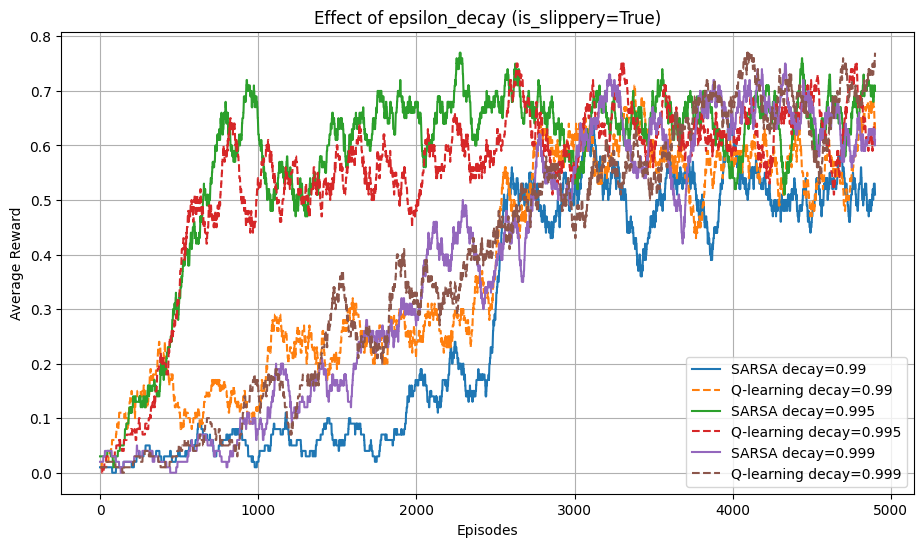


Win rate (greedy eval, tests=500):
decay=0.99: SARSA=0.624 | Q-learning=0.608
decay=0.995: SARSA=0.728 | Q-learning=0.748
decay=0.999: SARSA=0.726 | Q-learning=0.716


In [ ]:
# So sanh anh huong cua epsilon_decay 
def train_sarsa_with_decay(epsilon_decay, episodes=5000):
    Q = np.zeros((n_states, n_actions))
    epsilon_local = 1.0
    rewards = []

    for _ in range(episodes):
        state, _ = env.reset()
        action = epsilon_greedy(Q, state, epsilon_local)
        done = False
        total_reward = 0

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_action = epsilon_greedy(Q, next_state, epsilon_local)

            Q[state, action] += alpha * (
                reward + gamma * Q[next_state, next_action] - Q[state, action]
            )

            state, action = next_state, next_action
            total_reward += reward

        epsilon_local = max(epsilon_min, epsilon_local * epsilon_decay)
        rewards.append(total_reward)

    return Q, rewards


def train_qlearning_with_decay(epsilon_decay, episodes=5000):
    Q = np.zeros((n_states, n_actions))
    epsilon_local = 1.0
    rewards = []

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy(Q, state, epsilon_local)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            Q[state, action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )

            state = next_state
            total_reward += reward

        epsilon_local = max(epsilon_min, epsilon_local * epsilon_decay)
        rewards.append(total_reward)

    return Q, rewards


def moving_average(data, window=100):
    return np.convolve(data, np.ones(window) / window, mode="valid")


decays = [0.99, 0.995, 0.999]
results = {}

for d in decays:
    Qs, rs = train_sarsa_with_decay(d)
    Qq, rq = train_qlearning_with_decay(d)
    ws, _ = evaluate_policy(Qs, tests=500)
    wq, _ = evaluate_policy(Qq, tests=500)
    results[d] = {"sarsa_rewards": rs, "q_rewards": rq, "sarsa_win": ws, "q_win": wq}

plt.figure(figsize=(11, 6))
for d in decays:
    plt.plot(moving_average(results[d]["sarsa_rewards"]), label=f"SARSA decay={d}")
    plt.plot(moving_average(results[d]["q_rewards"]), linestyle="--", label=f"Q-learning decay={d}")

plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.title("Effect of epsilon_decay (is_slippery=True)")
plt.legend()
plt.grid(True)
plt.show()

print("\nWin rate (greedy eval, tests=500):")
for d in decays:
    print(f"decay={d}: SARSA={results[d]['sarsa_win']:.3f} | Q-learning={results[d]['q_win']:.3f}")

- decay=0.99: SARSA 0.624 > Q-learning 0.608

    - Giảm epsilon nhanh, SARSA nhỉnh hơn nhẹ (học thận trọng hơn nên đỡ rủi ro trong môi trường slippery).
- decay=0.995: Q-learning 0.748 > SARSA 0.728

    - Đây là cấu hình tốt nhất cho Q-learning trong 3 mức bạn test.
    - Cân bằng exploration/exploitation khá tốt, nên Q-learning phát huy off-policy update.
- decay=0.999: SARSA 0.726 > Q-learning 0.716

    - Exploration kéo dài hơn, SARSA lại nhỉnh hơn nhẹ.
    - Kết quả vẫn cao, nhưng không vượt được mốc tốt nhất của Q-learning ở 0.995.

KẾT LUẬN:   

- Cả hai thuật toán đều học tốt (win rate ~0.60–0.75).
    
- Q-learning tốt nhất tại epsilon_decay=0.995 (0.748).
    
- SARSA ổn định, thường nhỉnh hơn khi decay quá nhanh (0.99) hoặc quá chậm (0.999), phù hợp nhận định “an toàn hơn” trong môi trường stochastic.
    
- Chênh lệch giữa hai thuật toán không quá lớn, nên lựa chọn thuật toán phụ thuộc mục tiêu:
    
- ưu tiên hiệu suất đỉnh: Q-learning,
    
- ưu tiên hành vi thận trọng/ổn định: SARSA.

## Tra loi cau hoi C1-C5

**C1. Nguyen ly Q-learning va vi sao off-policy?**

Q-learning cap nhat theo Bellman optimality:
\[
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'}Q(s',a') - Q(s,a)\right]
\]
No la off-policy vi target dung \(\max_{a'}Q(s',a')\), tuc la hanh dong toi uu gia dinh, khong nhat thiet la hanh dong agent vua chon theo epsilon-greedy.

**C2. So sanh update Q-learning va SARSA**

- Q-learning: dung \(\max_{a'}Q(s',a')\) (toi uu gia dinh).
- SARSA: dung \(Q(s',a')\) voi \(a'\) thuc su chon theo policy hien tai.

He qua: SARSA thuong than trong hon trong moi truong rui ro (nhieu trap), con Q-learning thuong hung hang hon va co the dat reward cao hon neu kham pha du.

**C3. Vai tro epsilon-greedy; epsilon lon/nho**

- Epsilon giup can bang explore/exploit.
- Epsilon qua lon: agent kham pha nhieu, hoc cham, ket qua dao dong.
- Epsilon qua nho: de mac ket vao policy kem o giai doan dau.

**C4. Moi truong rui ro cao, thuat toan nao an toan hon?**

SARSA thuong an toan hon vi hoc theo hanh vi thuc te cua policy (co tinh den xac suat explore), nen tranh cac hanh dong sat trap tot hon trong moi truong stochastic.

**C5. Reward dao dong manh/khong tang: 3 nguyen nhan va khac phuc**

1. Epsilon decay khong phu hop (qua nhanh/qua cham) -> dieu chinh epsilon_decay, epsilon_min.
2. Learning rate alpha qua lon -> giam alpha (vd 0.1-0.2) de cap nhat on dinh hon.
3. So episode chua du hoac moi truong qua nhieu ngau nhien -> tang episodes, danh gia tren nhieu lan test va dung moving average de quan sat xu huong.

In [ ]:
# Tong reward theo episode (raw)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

if 'rewards_sarsa' in globals() and len(rewards_sarsa) > 0:
    plt.plot(rewards_sarsa, label='SARSA', alpha=0.8)

if 'rewards_q' in globals() and len(rewards_q) > 0:
    plt.plot(rewards_q, label='Q-learning', alpha=0.8)

plt.xlabel('Episode')
plt.ylabel('Total Reward per Episode')
plt.title('Total Reward per Episode (SARSA vs Q-learning)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

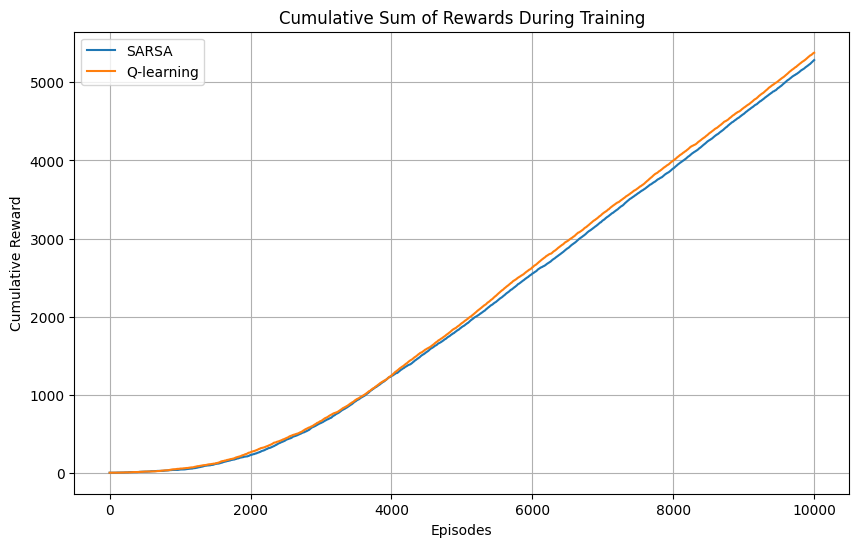

In [14]:
# Bieu do cumulative sum of rewards during episodes (chi SARSA va Q-learning)

cum_sarsa = np.cumsum(rewards_sarsa)
cum_q = np.cumsum(rewards_q)

plt.figure(figsize=(10, 6))
plt.plot(cum_sarsa, label="SARSA")
plt.plot(cum_q, label="Q-learning")

plt.xlabel("Episodes")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Sum of Rewards During Training")
plt.legend()
plt.grid(True)
plt.show()

Trên cumulative reward, cả SARSA và Q-learning đều hội tụ tốt; Q-learning đạt tổng reward cao hơn nhẹ, nhưng chênh lệch nhỏ cho thấy SARSA vẫn là lựa chọn cạnh tranh và ổn định trong môi trường stochastic.